# ABIDE Dataset

In [1]:
!pip install nilearn
!pip install matplotlib

  Using cached nilearn-0.11.1-py3-none-any.whl.metadata (9.3 kB)
  Using cached joblib-1.5.0-py3-none-any.whl.metadata (5.6 kB)
  Using cached lxml-5.4.0-cp312-cp312-win_amd64.whl.metadata (3.6 kB)
  Using cached nibabel-5.3.2-py3-none-any.whl.metadata (9.1 kB)
  Using cached idna-3.10-py3-none-any.whl.metadata (10 kB)
   ---------------------------------------- 0.0/10.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/10.5 MB ? eta -:--:--
   -- ------------------------------------- 0.5/10.5 MB 2.4 MB/s eta 0:00:05
   --- ------------------------------------ 0.8/10.5 MB 1.5 MB/s eta 0:00:07
   ----- ---------------------------------- 1.3/10.5 MB 1.8 MB/s eta 0:00:06
   --------- ------------------------------ 2.4/10.5 MB 2.5 MB/s eta 0:00:04
   ------------ --------------------------- 3.1/10.5 MB 2.9 MB/s eta 0:00:03
   --------------- ------------------------ 3.9/10.5 MB 3.0 MB/s eta 0:00:03
   ----------------- ---------------------- 4.5/10.5 MB 3.2 MB/s eta 0:00:02



[notice] A new release of pip is available: 24.3.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached kiwisolver-1.4.8-cp312-cp312-win_amd64.whl.metadata (6.3 kB)
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.1 MB 2.1 MB/s eta 0:00:04
   ----- ---------------------------------- 1.0/8.1 MB 2.2 MB/s eta 0:00:04
   ----- ---------------------------------- 1.0/8.1 MB 2.2 MB/s eta 0:00:04
   ------- -------------------------------- 1.6/8.1 MB 1.7 MB/s eta 0:00:04
   ---------- ----------------------------- 2.1/8.1 MB 1.8 MB/s eta 0:00:04
   ------------ --------------------------- 2.6/8.1 MB 1.9 MB/s eta 0:00:03
   --------------- ------------------------ 3.1/8.1 MB 2.0 MB/s eta 0:00:03
   ---------------- ----------------------- 3.4/8.1 MB 2.0 MB/s eta 0:00:03
   ------------------ --------------------- 3.7/8.1 MB 2.0 MB/s eta 0:00:03
   ------------------ ----------------


[notice] A new release of pip is available: 24.3.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import numpy as np
from nilearn.datasets import fetch_abide_pcp
from nilearn.input_data import NiftiLabelsMasker, NiftiSpheresMasker
from nilearn import datasets

In [ ]:
# Download data for specified subjects
subjects_num = None
abide = fetch_abide_pcp(n_subjects=subjects_num, pipeline='cpac', derivatives=['func_preproc'])

[get_dataset_dir] Dataset found in D:\Programs\DNA\Data\ABIDE_pcp


In [5]:
phenotypic = abide['phenotypic']
phenotypic = phenotypic.reset_index(drop=True)

In [6]:
phenotypic['DX_GROUP'].value_counts()

DX_GROUP
2    468
1    403
Name: count, dtype: int64

In [ ]:
dosenbach = datasets.fetch_coords_dosenbach_2010()
coords = dosenbach['rois'][['x', 'y', 'z']].values
roi_labels = dosenbach['labels']

In [ ]:
masker = NiftiSpheresMasker(seeds=coords, radius=8, standardize=True, allow_overlap=True)

In [9]:
time_series_list = []
count = 0
for func_file in abide['func_preproc']:
    count +=1
    ts = masker.fit_transform(func_file)
    time_series_list.append(ts)
    print(f'{count}/{len(abide['func_preproc'])}')

1/871
2/871
3/871
4/871
5/871
6/871
7/871
8/871
9/871
10/871
11/871
12/871
13/871
14/871
15/871
16/871
17/871
18/871
19/871
20/871
21/871
22/871
23/871
24/871
25/871
26/871
27/871
28/871
29/871
30/871
31/871
32/871
33/871
34/871
35/871
36/871
37/871
38/871
39/871
40/871
41/871
42/871
43/871
44/871
45/871
46/871
47/871
48/871
49/871
50/871
51/871
52/871
53/871
54/871
55/871
56/871
57/871
58/871
59/871
60/871
61/871
62/871
63/871
64/871
65/871
66/871
67/871
68/871
69/871
70/871
71/871
72/871
73/871
74/871
75/871
76/871
77/871
78/871
79/871
80/871
81/871
82/871
83/871
84/871
85/871
86/871
87/871
88/871
89/871
90/871
91/871
92/871
93/871
94/871
95/871
96/871
97/871
98/871
99/871
100/871
101/871
102/871
103/871
104/871
105/871
106/871
107/871
108/871
109/871
110/871
111/871
112/871
113/871
114/871
115/871
116/871
117/871
118/871
119/871
120/871
121/871
122/871
123/871
124/871
125/871
126/871
127/871
128/871
129/871
130/871
131/871
132/871
133/871
134/871
135/871
136/871
137/871
138/871
139/

In [10]:
control_indices = phenotypic[phenotypic['DX_GROUP'] == 1].index
disease_indices = phenotypic[phenotypic['DX_GROUP'] == 2].index

control_time_series = [time_series_list[i] for i in control_indices]
disease_time_series = [time_series_list[i] for i in disease_indices]

In [ ]:
# this calculate covariance for each individual with its time series data
# we have a covariance matrix for each individual
from nilearn.connectome import ConnectivityMeasure

cov_measure = ConnectivityMeasure(kind='covariance')

control_covariances = cov_measure.fit_transform(control_time_series)
disease_covariances = cov_measure.fit_transform(disease_time_series)

## Differential Network Analysis Between Autism and Control Groups

In [ ]:
# Estimate the covariance matrices for each group.

import numpy as np
np.random.seed(1)

## Estimate of covariance matrix in "control" samples
number_of_control_samples = control_covariances.shape[0]

indices = np.random.permutation(number_of_control_samples)
ols_indices = indices[:int(number_of_control_samples/2)]
lasso_indices = indices[int(number_of_control_samples/2):]

# Calculate means
ols_control_covariance = np.mean(control_covariances[ols_indices], axis=0)
lasso_control_covariance = np.mean(control_covariances[lasso_indices], axis=0)

## Estimate of covariance matrix in "disease" samples
number_of_disease_samples = disease_covariances.shape[0]

indices = np.random.permutation(number_of_disease_samples)
ols_indices = indices[:int(number_of_disease_samples/2)]
lasso_indices = indices[int(number_of_disease_samples/2):]

ols_disease_covariance = np.mean(disease_covariances[ols_indices], axis=0)
lasso_disease_covariance = np.mean(disease_covariances[lasso_indices], axis=0)

In [ ]:
# Compute e-values

import importlib
import library
importlib.reload(library)
from library import *

dimension = lasso_control_covariance.shape[0]
# get ols delta hat
# d2==disease, d1==control
ols_delta_hat = get_delta_hat(ols_disease_covariance, ols_control_covariance)

maximum_identified_edge = 100
# get lasso delta hat
lasso_delta_hat, e_values, evals = run_lasso(lasso_s_cov_1=lasso_control_covariance,
                                             lasso_s_cov_2=lasso_disease_covariance,
                                             ols_delta_hat=ols_delta_hat,
                                             c=maximum_identified_edge)
p = len(list(ols_delta_hat[np.triu_indices(dimension,k=0)]))
l = len(evals)

Library imported
Library imported
Library imported
Library imported
Library imported
Library imported
differential network length:  0
differential network length:  2
differential network length:  4
differential network length:  6
differential network length:  8
differential network length:  10
differential network length:  12
differential network length:  14
differential network length:  16
differential network length:  18
differential network length:  20
differential network length:  22
differential network length:  24
differential network length:  26
differential network length:  28
differential network length:  30
differential network length:  32
differential network length:  34
differential network length:  36
differential network length:  38
differential network length:  40
differential network length:  42
differential network length:  44
differential network length:  46
differential network length:  48
differential network length:  50
differential network length:  52
differential

In [ ]:
# Apply e-BH procedure

maximum_acceptable_fdr = 0.5
k_hat = 0
max_e = 0
evals[0] = np.nan
for k in range(1,l):
    e = np.count_nonzero(list(e_values[k][np.triu_indices(dimension,k=0)]))
    if e > 0 and evals[k] != 0 and evals[k] >= p / (maximum_acceptable_fdr * e) and max_e < e:
        k_hat = k
        max_e = e

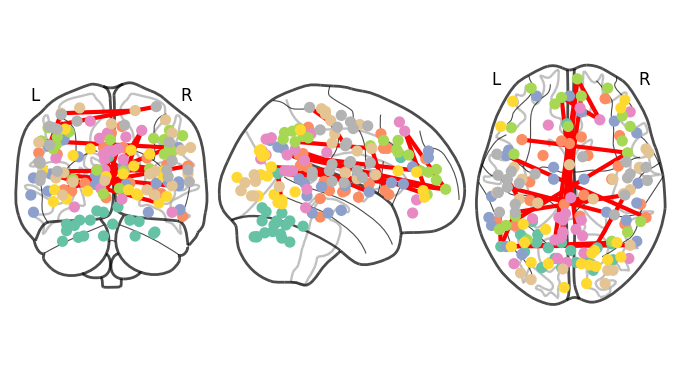

In [ ]:
# Plot the differences in the network structure.

from nilearn.plotting import plot_connectome

img = plot_connectome(adjacency_matrix=e_values[k_hat], node_coords=coords)
img.savefig('Results/brain.pdf')


# Validation

In [ ]:
from rpy2 import robjects
from rpy2.robjects import pandas2ri
from rpy2.robjects import numpy2ri
from rpy2.robjects.vectors import FloatVector

def DNetFinder_Liu2017(XA, XB, alpha):
    pandas2ri.activate()
    numpy2ri.activate()
    # Convert Python lists or arrays to numpy arrays and ensure they are C-contiguous
    XA = np.ascontiguousarray(XA)
    XB = np.ascontiguousarray(XB)
    alpha = np.ascontiguousarray(alpha)
  
    # Source your R code
    robjects.r.source('R_codes/Libraray.R')
    r_func = robjects.globalenv['DNetFinder_Liu2017_method']

    # Convert Python arrays to R matrices
    r_XA = robjects.r.matrix(XA, nrow=XA.shape[0], ncol=XA.shape[1])
    r_XB = robjects.r.matrix(XB, nrow=XB.shape[0], ncol=XB.shape[1])
    r_alpha = robjects.FloatVector([alpha])[0]  # Your code (verbose)
  
    # Call the R function
    output = r_func(r_XA, r_XB, r_alpha)

    return output



In [ ]:
# Evaluation of DiffNetFinder Liu 2017

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import numpy as np

np.random.seed(1)

def compute_roi_pairwise_products_mean(time_series_list, mask):
    all_subject_means = []
    counter=1
    for ts in time_series_list:  # ts shape: (n_timepoints, n_rois)
        counter = counter+1
        n_rois = ts.shape[1]
        roi_means = []
        for i in range(n_rois):
            for j in range(n_rois):
                if mask[i,j] != 0:
                    # Element-wise multiplication of time series and mean over time
                    roi_means.append(np.mean(ts[:, i] * ts[:, j]))
        all_subject_means.append(roi_means)
    return all_subject_means


# Example self-defined feature selector: Selects top k features by variance
class DiffNetFinder_Liu2017(BaseEstimator, TransformerMixin):
    fit_calls = 0  # Counter for fit calls

    def __init__(self, alpha=0.5):
        self.alpha = alpha

    def fit(self, X, y=None):
        print(f"\nfit: count: {DiffNetFinder_Liu2017.fit_calls}")
        DiffNetFinder_Liu2017.fit_calls += 1  # Increment counter

        y = np.array(y)
        control_indices = np.where(y == 1)[0]  # This returns an array of indices
        disease_indices = np.where(y == 2)[0]  # This returns an array of indices

        print(f"fit: X len:{len(X)}")

        control_time_series = [X[i] for i in control_indices]
        disease_time_series = [X[i] for i in disease_indices]
        
        control_means = np.vstack([np.mean(ts, axis=0) for ts in control_time_series])
        disease_means = np.vstack([np.mean(ts, axis=0) for ts in disease_time_series])

        print(f"fit: control shape:{control_means.shape}")
        print(f"fit: disease shape:{disease_means.shape}")

        self.mask = DNetFinder_Liu2017(XA=control_means, XB=disease_means, alpha=self.alpha)
        print(f"fit: number of selected feature:{np.count_nonzero(self.mask)}")
        
        return self

    def transform(self, X):
        print(f"transform: X len:{len(X)}")
        samples_means = compute_roi_pairwise_products_mean(X, self.mask)
        X_transformed = np.stack(samples_means)
        print(f"transform: X_transformed shape:{X_transformed.shape}")
        if X_transformed.shape[1] == 0:
            X_transformed = np.zeros((len(X), 1))
        print(f"transform: X_transformed shape:{X_transformed.shape}")
        return X_transformed


fit: count: 0
fit: X len:464
fit: control shape:(215, 160)
fit: disease shape:(249, 160)
fit: number of selected feature:0
transform: X len:464
transform: X_transformed shape:(464, 0)
transform: X_transformed shape:(464, 1)
transform: X len:232
transform: X_transformed shape:(232, 0)
transform: X_transformed shape:(232, 1)

fit: count: 1
fit: X len:464
fit: control shape:(215, 160)
fit: disease shape:(249, 160)
fit: number of selected feature:4
transform: X len:464
transform: X_transformed shape:(464, 4)
transform: X_transformed shape:(464, 4)
transform: X len:232
transform: X_transformed shape:(232, 4)
transform: X_transformed shape:(232, 4)

fit: count: 2
fit: X len:464
fit: control shape:(214, 160)
fit: disease shape:(250, 160)
fit: number of selected feature:14
transform: X len:464
transform: X_transformed shape:(464, 14)
transform: X_transformed shape:(464, 14)
transform: X len:232
transform: X_transformed shape:(232, 14)
transform: X_transformed shape:(232, 14)

fit: count: 3
fi

In [159]:
repetition = 30
accuracies = []
for counter in range(repetition):
    print(f"\n\n#########################################\nCount: {counter}")
    
    # Split into train+val and test (80%/20%)
    X_trainval, X_test, y_trainval, y_test = train_test_split(
        time_series_list, phenotypic['DX_GROUP'].tolist(), test_size=0.2, stratify=phenotypic['DX_GROUP'].tolist(), random_state=1
    )

    # Pipeline: feature selection + model
    pipeline = Pipeline([
        ('feature_selection', DiffNetFinder_Liu2017()), 
        ('classifier', LogisticRegression(max_iter=1000, solver='liblinear', fit_intercept=True))
    ])

    # Grid search over both regularization and number of features
    param_grid = {
        'classifier__C': [0.01, 1, 100],     # Regularization strength
        'feature_selection__alpha': [0.1, 0.25, 0.5, 0.75, 0.9],
    }

    grid = GridSearchCV(pipeline, param_grid, cv=3)
    grid.fit(X_trainval, y_trainval)

    # Evaluate final model on test set
    test_preds = grid.predict(X_test)
    test_acc = accuracy_score(y_test, test_preds)
    print("Test Accuracy:", test_acc)
    print("Best Parameters:", grid.best_params_)

    accuracies.append(test_acc)


print("Mean Test Accuracy:", np.mean(accuracies))



fit: count: 0
fit: X len:464
fit: control shape:(215, 160)
fit: disease shape:(249, 160)
fit: number of selected feature:0
transform: X len:464
transform: X_transformed shape:(464, 0)
transform: X_transformed shape:(464, 1)
transform: X len:232
transform: X_transformed shape:(232, 0)
transform: X_transformed shape:(232, 1)

fit: count: 1
fit: X len:464
fit: control shape:(215, 160)
fit: disease shape:(249, 160)
fit: number of selected feature:4
transform: X len:464
transform: X_transformed shape:(464, 4)
transform: X_transformed shape:(464, 4)
transform: X len:232
transform: X_transformed shape:(232, 4)
transform: X_transformed shape:(232, 4)

fit: count: 2
fit: X len:464
fit: control shape:(214, 160)
fit: disease shape:(250, 160)
fit: number of selected feature:14
transform: X len:464
transform: X_transformed shape:(464, 14)
transform: X_transformed shape:(464, 14)
transform: X len:232
transform: X_transformed shape:(232, 14)
transform: X_transformed shape:(232, 14)

fit: count: 3
fi

In [ ]:
# Evaluation of our proposed method

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import numpy as np

np.random.seed(1)

def compute_roi_pairwise_products_mean(time_series_list, mask):
    all_subject_means = []
    counter=1
    for ts in time_series_list:  # ts shape: (n_timepoints, n_rois)
        counter = counter+1
        n_rois = ts.shape[1]
        roi_means = []
        for i in range(n_rois):
            for j in range(n_rois):
                if mask[i,j] != 0:
                    # Element-wise multiplication of time series and mean over time
                    roi_means.append(np.mean(ts[:, i] * ts[:, j]))
        all_subject_means.append(roi_means)
    return all_subject_means


# Example self-defined feature selector: Selects top k features by variance
class DNetEx(BaseEstimator, TransformerMixin):
    fit_calls = 0  # Counter for fit calls

    def __init__(self, alpha=0.5, c=50):
        self.alpha = alpha
        self.c = c

    def fit(self, X, y=None):
        print(f"\nfit: count: {DNetEx.fit_calls}")
        DNetEx.fit_calls += 1  # Increment counter

        y = np.array(y)
        control_indices = np.where(y == 1)[0]  # This returns an array of indices
        disease_indices = np.where(y == 2)[0]  # This returns an array of indices

        print(f"fit: X len:{len(X)}")

        control_time_series = [X[i] for i in control_indices]
        disease_time_series = [X[i] for i in disease_indices]
        
        cov_measure = ConnectivityMeasure(kind='covariance')

        control_covariances = cov_measure.fit_transform(control_time_series)
        disease_covariances = cov_measure.fit_transform(disease_time_series)

        first_eval = 0
        while first_eval == 0:
            ### Algorithm
            ## Estimate of covariance matrix in "control" samples
            number_of_control_samples = control_covariances.shape[0]

            indices = np.random.permutation(number_of_control_samples)
            ols_indices = indices[:int(number_of_control_samples/2)]
            lasso_indices = indices[int(number_of_control_samples/2):]

            # Calculate means
            ols_control_covariance = np.mean(control_covariances[ols_indices], axis=0)
            lasso_control_covariance = np.mean(control_covariances[lasso_indices], axis=0)

            ## Estimate of covariance matrix in "disease" samples
            number_of_disease_samples = disease_covariances.shape[0]

            indices = np.random.permutation(number_of_disease_samples)
            ols_indices = indices[:int(number_of_disease_samples/2)]
            lasso_indices = indices[int(number_of_disease_samples/2):]

            ols_disease_covariance = np.mean(disease_covariances[ols_indices], axis=0)
            lasso_disease_covariance = np.mean(disease_covariances[lasso_indices], axis=0)

            ###############################
            dimension = lasso_control_covariance.shape[0]
            # get ols delta hat
            # d2==disease, d1==control
            ols_delta_hat = get_delta_hat(ols_disease_covariance, ols_control_covariance)

            maximum_identified_edge = self.c
            # get lasso delta hat
            lasso_delta_hat, e_values, evals = run_lasso(lasso_s_cov_1=lasso_control_covariance,
                                                        lasso_s_cov_2=lasso_disease_covariance,
                                                        ols_delta_hat=ols_delta_hat,
                                                        c=maximum_identified_edge)
            l = len(evals)

            ################################
            maximum_acceptable_fdr = self.alpha
            k_hat = 0
            max_e = 0
            evals[0] = np.nan
            for k in range(1,l):
                e = np.count_nonzero(list(e_values[k][np.triu_indices(dimension,k=0)]))
                if e > 0 and evals[k] != 0 and evals[k] >= p / (maximum_acceptable_fdr * e) and max_e < e:
                    k_hat = k
                    max_e = e
            first_eval = evals[1]

        ################################
        print(f"k_hat: {k_hat}")
        print(f"evals: {evals}")
        self.mask = e_values[k_hat]
        print(f"fit: number of selected feature:{np.count_nonzero(self.mask)}")
        
        return self

    def transform(self, X):
        print(f"transform: X len:{len(X)}")
        samples_means = compute_roi_pairwise_products_mean(X, self.mask)
        X_transformed = np.stack(samples_means)
        print(f"transform: X_transformed shape:{X_transformed.shape}")
        if X_transformed.shape[1] == 0:
            X_transformed = np.zeros((len(X), 1))
        print(f"transform: X_transformed shape:{X_transformed.shape}")
        return X_transformed




fit: count: 0
fit: X len:464
differential network length:  0
differential network length:  2
differential network length:  4
differential network length:  6
differential network length:  8
differential network length:  10
differential network length:  12
differential network length:  14
differential network length:  16
differential network length:  18
differential network length:  20
differential network length:  22
differential network length:  24
differential network length:  26
differential network length:  28
differential network length:  30
differential network length:  32
differential network length:  34
differential network length:  36
differential network length:  38
differential network length:  40
differential network length:  42
differential network length:  44
differential network length:  46
differential network length:  48
k_hat: 0
evals: [nan, np.float64(12880.0), np.float64(6440.0), np.float64(6440.0), np.float64(6440.0), np.float64(4293.333333333333), np.float64(3220.

In [ ]:
repetition = 30
accuracies = []
for counter in range(repetition):
    print(f"\n\n#########################################\nCount: {counter}")
    # Split into train+val and test (80%/20%)
    X_trainval, X_test, y_trainval, y_test = train_test_split(
        time_series_list, phenotypic['DX_GROUP'].tolist(), test_size=0.2, stratify=phenotypic['DX_GROUP'].tolist(), random_state=1
    )

    # Pipeline: feature selection + model
    pipeline = Pipeline([
        ('feature_selection', DNetEx()), 
        ('classifier', LogisticRegression(max_iter=1000, solver='liblinear', fit_intercept=True))
    ])

    # Grid search over both regularization and number of features
    param_grid = {
        'classifier__C': [0.01, 1, 100],     # Regularization strength
        'feature_selection__alpha': [0.1, 0.25, 0.5, 0.75, 0.9],
        'feature_selection__c': [40],
    }

    grid = GridSearchCV(pipeline, param_grid, cv=3)
    grid.fit(X_trainval, y_trainval)

    # Evaluate final model on test set
    test_preds = grid.predict(X_test)
    test_acc = accuracy_score(y_test, test_preds)
    print("Test Accuracy:", test_acc)
    print("Best Parameters:", grid.best_params_)

    accuracies.append(test_acc)


print("Mean Test Accuracy:", np.mean(accuracies))



#########################################
Count: 0

fit: count: 72
fit: X len:464
differential network length:  0
differential network length:  2
differential network length:  4
differential network length:  6
differential network length:  8
differential network length:  10
differential network length:  12
differential network length:  14
differential network length:  16
differential network length:  18
differential network length:  20
differential network length:  22
differential network length:  24
differential network length:  26
differential network length:  28
differential network length:  30
differential network length:  32
differential network length:  34
differential network length:  36
differential network length:  38
differential network length:  0
differential network length:  2
differential network length:  4
differential network length:  6
differential network length:  8
differential network length:  10
differential network length:  12
differential network length:  14
di